In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys, os
from pathlib import Path

project_root = Path(os.getcwd()).parent if 'spaghetti_code' in os.getcwd() else Path(os.getcwd())
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from cs_priors.plotting.plot_complex import plot_matrices
from cs_priors.simulation.mixing_model import quick_sector_sim, quick_sim
from cs_priors.solvers.group_lasso import group_lasso_solve
from cs_priors.plotting.plot_signals import plot_recovery
from cs_priors.plotting.plot_geometry import plot_geometry_on_ax
from cs_priors.metrics.count_sparsity import (
    noise_threshold,
    active_sources,
    source_energies,
    detection_scores,
    relative_error,
    score,
)
from cs_priors.metrics.benchmark import run_methods, score_methods, grid_benchmark, heatmap_benchmark
from cs_priors.solvers.vectorized_sparse_prior import sparse_prior_solution
from cs_priors.solvers.group_lasso import _to_block_system

def sparse_prior_solve(sim):
    A_block, Y_block, S, N = _to_block_system(sim)
    X_flat = sparse_prior_solution(Y_block, A_block)
    return X_flat.reshape(S, N)

from cs_priors.solvers.complex_lasso import complex_lasso

def complex_lasso_solve(sim, alpha=1e-4):
    A_block, Y_block, S, N = _to_block_system(sim)
    X_flat = complex_lasso(Y_block, A_block, alpha=alpha)
    return X_flat.reshape(S, N)

# Performance Benchmark
Compare Group LASSO grouping strategies on arc simulations.

$F_1 = \frac{2tp}{2tp + fp + fn}$

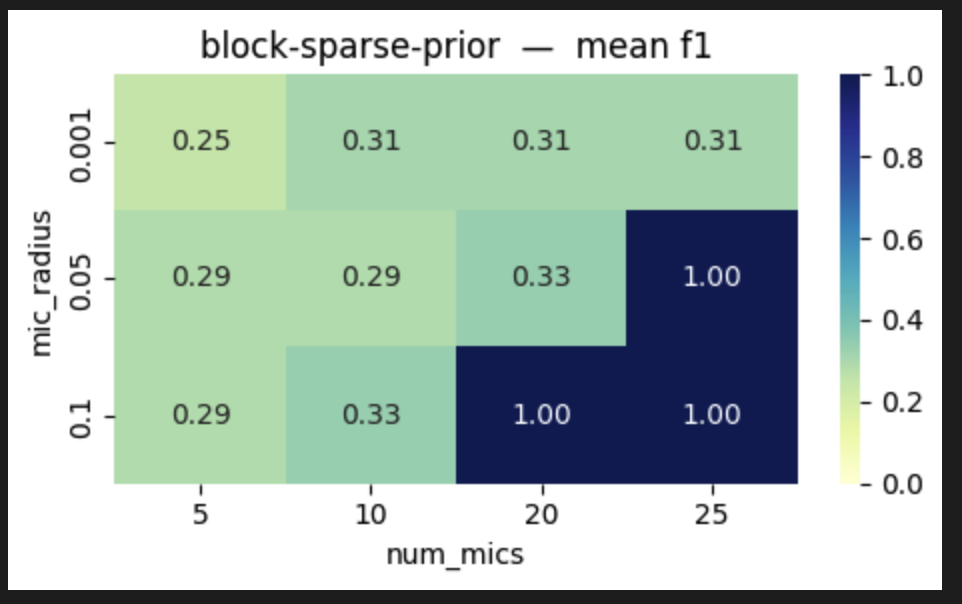

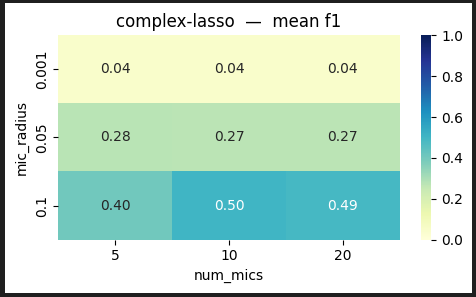

In [ ]:


num_sources = 10
num_seeds = 11
simulation_type = quick_sim

param_grid = {
    "num_mics":    [3,6,9],
    "num_sources": [num_sources],
    "num_active":  [2,4],
    "source_distance": [0.2],
    "mic_radius": [0.01],
}

# Visualize the simulation we will be working with
dummy_sim = simulation_type(num_mics=param_grid["num_mics"][0], num_sources=param_grid["num_sources"][0], num_active=param_grid["num_active"][0], seed=0, source_distance=param_grid["source_distance"][0], mic_radius=param_grid["mic_radius"][0])
plot_geometry_on_ax(ax=plt.gca(), mics=dummy_sim.mics, sources=dummy_sim.sources, pad_factor=0.02)
plt.title("Example Simulation Geometry")
plt.show()

plot_matrices([dummy_sim.A[0], dummy_sim.Y, dummy_sim.X, dummy_sim.X_pinv], titles=["Mixing Matrix A", "Measurements Y", "True Sources X", "Pseudoinverse Solution X_pinv"], show_values=False)
plt.show()

In [ ]:
# ── solvers to compare ───────────────────────────────────────────────────────

methods = {
    # "GL-frequency":  lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="frequency"),
    # "GL-real_imag":  lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="real_imag"),
    # "GL-none":       lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="none"),
    "block-sparse-prior": lambda sim: sparse_prior_solve(sim),
}

# ── run benchmark & plot heatmaps ────────────────────────────────────────────
df_block_sparse_prior = heatmap_benchmark(
    sim_factory=simulation_type,
    param_grid=param_grid,
    methods=methods,
    num_seeds=num_seeds,
    pivot_x="num_mics",
    pivot_y="mic_radius",
    metric="f1",
    n_jobs=-1,
)

df_block_sparse_prior.tail()

In [ ]:
methods = {"complex-lasso": lambda sim: complex_lasso_solve(sim, alpha=1e-4),}

# ── run benchmark & plot heatmaps ────────────────────────────────────────────
df_complex_lasso = heatmap_benchmark(
    sim_factory=quick_sector_sim,
    param_grid=param_grid,
    methods=methods,
    num_seeds=num_seeds,
    pivot_x="num_mics",
    pivot_y="mic_radius",
    metric="f1",
    n_jobs=-1,
)

df_complex_lasso.tail()

In [ ]:
methods = {
    "GL-frequency_1e-5":  lambda sim: group_lasso_solve(sim, alpha=1e-5, grouping="frequency"),
    # "GL-real_imag":  lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="real_imag"),
    # "GL-none":       lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="none"),
    # "block-sparse-prior": lambda sim: sparse_prior_solve(sim),
}

# ── run benchmark & plot heatmaps ────────────────────────────────────────────
df_gl_frequency_1e5 = heatmap_benchmark(
    sim_factory=quick_sector_sim,
    param_grid=param_grid,
    methods=methods,
    num_seeds=num_seeds,
    pivot_x="num_mics",
    pivot_y="mic_radius",
    metric="f1",
    n_jobs=-1,
)

df_gl_frequency_1e5.tail()

In [ ]:
methods = {
    "GL-frequency_1e-6":  lambda sim: group_lasso_solve(sim, alpha=1e-6, grouping="frequency"),
    # "GL-real_imag":  lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="real_imag"),
    # "GL-none":       lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="none"),
    # "block-sparse-prior": lambda sim: sparse_prior_solve(sim),
}

# ── run benchmark & plot heatmaps ────────────────────────────────────────────
df_gl_frequency_1e6 = heatmap_benchmark(
    sim_factory=quick_sector_sim,
    param_grid=param_grid,
    methods=methods,
    num_seeds=num_seeds,
    pivot_x="num_mics",
    pivot_y="mic_radius",
    metric="f1",
    n_jobs=-1,
)

df_gl_frequency_1e6.tail()

In [ ]:
methods = {
    "GL-frequency_1e-7":  lambda sim: group_lasso_solve(sim, alpha=1e-7, grouping="frequency"),
    # "GL-real_imag":  lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="real_imag"),
    # "GL-none":       lambda sim: group_lasso_solve(sim, alpha=alpha, grouping="none"),
    # "block-sparse-prior": lambda sim: sparse_prior_solve(sim),
}

# ── run benchmark & plot heatmaps ────────────────────────────────────────────
df_gl_frequency_1e7 = heatmap_benchmark(
    sim_factory=quick_sector_sim,
    param_grid=param_grid,
    methods=methods,
    num_seeds=num_seeds,
    pivot_x="num_mics",
    pivot_y="mic_radius",
    metric="f1",
    n_jobs=-2,
)

df_gl_frequency_1e7.tail()

In [ ]:
methods = {
    "GL-frequency_1e-8":  lambda sim: group_lasso_solve(sim, alpha=1e-8, grouping="frequency"),
}

# ── run benchmark & plot heatmaps ────────────────────────────────────────────
df_gl_frequency_1e8 = heatmap_benchmark(
    sim_factory=quick_sector_sim,
    param_grid=param_grid,
    methods=methods,
    num_seeds=num_seeds,
    pivot_x="num_mics",
    pivot_y="mic_radius",
    metric="f1",
    n_jobs=-2,
)

df_gl_frequency_1e8.tail()